<p style="align: center;"><img src="https://static.tildacdn.com/tild6636-3531-4239-b465-376364646465/Deep_Learning_School.png" width="400"></p>

# Домашнее задание. Нейросетевая классификация текстов

В этом домашнем задании вам предстоит самостоятельно решить задачу классификации текстов на основе семинарского кода. Мы будем использовать датасет [ag_news](https://paperswithcode.com/dataset/ag-news). Это датасет для классификации новостей на 4 темы: "World", "Sports", "Business", "Sci/Tech".

Установим модуль datasets, чтобы нам проще было работать с данными.

In [1]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 487.4/487.4 kB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 20.2 MB/s eta 0:00:00


Импорт необходимых библиотек

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import datasets

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from datasets import load_dataset
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
import nltk

from collections import Counter
from typing import List
import string

import seaborn
seaborn.set(palette='summer')

In [3]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [4]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [5]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Подготовка данных
Для вашего удобства, мы привели код обработки датасета в ноутбуке. Ваша задача --- обучить модель, которая получит максимальное возможное качество на тестовой части.

In [6]:
# Загрузим датасет
dataset = datasets.load_dataset('ag_news')

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Как и в семинаре, выполним следующие шаги:
* Составим словарь
* Создадим класс WordDataset
* Выделим обучающую и тестовую часть, создадим DataLoader-ы.

In [7]:
words = Counter()

for example in tqdm(dataset['train']['text']):
    # Приводим к нижнему регистру и убираем пунктуацию
    prccessed_text = example.lower().translate(
        str.maketrans('', '', string.punctuation))

    for word in word_tokenize(prccessed_text):
        words[word] += 1


vocab = set(['<unk>', '<bos>', '<eos>', '<pad>'])
counter_threshold = 25

for char, cnt in words.items():
    if cnt > counter_threshold:
        vocab.add(char)

print(f'Размер словаря: {len(vocab)}')

word2ind = {char: i for i, char in enumerate(vocab)}
ind2word = {i: char for char, i in word2ind.items()}

  0%|          | 0/120000 [00:00<?, ?it/s]

Размер словаря: 11842


In [8]:
class WordDataset:
    def __init__(self, sentences):
        self.data = sentences
        self.unk_id = word2ind['<unk>']
        self.bos_id = word2ind['<bos>']
        self.eos_id = word2ind['<eos>']
        self.pad_id = word2ind['<pad>']

    def __getitem__(self, idx: int) -> List[int]:
        processed_text = self.data[idx]['text'].lower().translate(
            str.maketrans('', '', string.punctuation))
        tokenized_sentence = [self.bos_id]
        tokenized_sentence += [
            word2ind.get(word, self.unk_id) for word in word_tokenize(processed_text)
            ]
        tokenized_sentence += [self.eos_id]

        train_sample = {
            "text": tokenized_sentence,
            "label": self.data[idx]['label']
        }

        return train_sample

    def __len__(self) -> int:
        return len(self.data)


def collate_fn_with_padding(
    input_batch: List[List[int]], pad_id=word2ind['<pad>'], max_len=256) -> torch.Tensor:
    seq_lens = [len(x['text']) for x in input_batch]
    max_seq_len = min(max(seq_lens), max_len)

    new_batch = []
    for sequence in input_batch:
        sequence['text'] = sequence['text'][:max_seq_len]
        for _ in range(max_seq_len - len(sequence['text'])):
            sequence['text'].append(pad_id)

        new_batch.append(sequence['text'])

    sequences = torch.LongTensor(new_batch).to(device)
    labels = torch.LongTensor([x['label'] for x in input_batch]).to(device)

    new_batch = {
        'input_ids': sequences,
        'label': labels
    }

    return new_batch

In [9]:
train_dataset = WordDataset(dataset['train'])

np.random.seed(42)
idx = np.random.choice(np.arange(len(dataset['test'])), 5000)
eval_dataset = WordDataset(dataset['test'].select(idx))

batch_size = 32
train_dataloader = DataLoader(
    train_dataset, shuffle=True, collate_fn=collate_fn_with_padding, batch_size=batch_size)

eval_dataloader = DataLoader(
    eval_dataset, shuffle=False, collate_fn=collate_fn_with_padding, batch_size=batch_size)

## Постановка задачи
Ваша задача -- получить максимальное возможное accuracy на `eval_dataloader`. Ниже приведена функция, которую вам необходимо запустить для обученной модели, чтобы вычислить качество её работы.

In [10]:
def evaluate(model, eval_dataloader) -> float:
    """
    Calculate accuracy on validation dataloader.
    """

    predictions = []
    target = []
    with torch.no_grad():
        for batch in eval_dataloader:
            logits = model(batch['input_ids'])
            predictions.append(logits.argmax(dim=1))
            target.append(batch['label'])

    predictions = torch.cat(predictions)
    target = torch.cat(target)
    accuracy = (predictions == target).float().mean().item()

    return accuracy

## Ход работы
Оценка за домашнее задание складывается из четырех частей:
### Запуск базовой модели с семинара на новом датасете (1 балл)
На семинаре мы создали модель, которая дает на нашей задаче довольно высокое качество. Ваша цель --- обучить ее и вычислить `score`, который затем можно будет использовать в качестве бейзлайна.

В модели появится одно важное изменение: количество классов теперь равно не 2, а 4. Обратите на это внимание и найдите, что в коде создания модели нужно модифицировать, чтобы учесть это различие.

### Проведение экспериментов по улучшению модели (2 балла за каждый эксперимент)
Чтобы улучшить качество базовой модели, можно попробовать различные идеи экспериментов. Каждый выполненный эксперимент будет оцениваться в 2 балла. Для получения полного балла за этот пункт вам необходимо выполнить по крайней мере 2 эксперимента. Не расстраивайтесь, если какой-то эксперимент не дал вам прироста к качеству: он все равно зачтется, если выполнен корректно.

Вот несколько идей экспериментов:
* **Модель RNN**. Попробуйте другие нейросетевые модели --- LSTM и GRU. Мы советуем обратить внимание на [GRU](https://pytorch.org/docs/stable/generated/torch.nn.GRU.html), так как интерфейс этого класса ничем не отличается от обычной Vanilla RNN, которую мы использовали на семинаре.
* **Увеличение количества рекуррентных слоев модели**. Это можно сделать с помощью параметра `num_layers` в классе `nn.RNN`. В такой модели выходы первой RNN передаются в качестве входов второй RNN и так далее.
* **Изменение архитектуры после применения RNN**. В базовой модели используется агрегация со всех эмбеддингов. Возможно, вы захотите конкатенировать результат агрегации и эмбеддинг с последнего токена.
* **Подбор гиперпараметров и обучение до сходимости**. Возможно, для получения более высокого качества просто необходимо увеличить количество эпох обучения нейросети, а также попробовать различные гиперпараметры: размер словаря, `dropout_rate`, `hidden_dim`.

Обратите внимание, что главное правило проведения экспериментов --- необходимо совершать одно архитектурное изменение в одном эксперименте. Если вы совершите несколько изменений, то будет неясно, какое именно из изменений дало прирост к качеству.

### Получение высокого качества (3 балла)
В конце вашей работы вы должны указать, какая из моделей дала лучший результат, и вывести качество, которое дает лучшая модель, с помощью функции `evaluate`. Ваша модель будет оцениваться по метрике `accuracy` следующим образом:
* $accuracy < 0.9$ --- 0 баллов;
* $0.9 \leqslant accuracy < 0.91$ --- 1 балл;
* $0.91 \leqslant accuracy < 0.915$ --- 2 балла;
* $0.915 \leqslant accuracy$ --- 3 балла.

### Оформление отчета (2 балла)
В конце работы подробно опишите все проведенные эксперименты.
* Укажите, какие из экспериментов принесли улучшение, а какие --- нет.
* Проанализируйте графики сходимости моделей в проведенных экспериментах. Являются ли колебания качества обученных моделей существенными в зависимости от эпохи обучения, или же сходимость стабильная?
* Укажите, какая модель получилась оптимальной.

Желаем удачи!

## Модель с семинара

In [11]:
class CharLM(nn.Module):
    def __init__(
        self, hidden_dim: int, vocab_size: int, num_classes: int = 4,
        aggregation_type: str = 'max'
        ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.RNN(hidden_dim, hidden_dim, batch_first=True)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, num_classes)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

        self.aggregation_type = aggregation_type

    def forward(self, input_batch) -> torch.Tensor:
        embeddings = self.embedding(input_batch)  # [batch_size, seq_len, hidden_dim]
        output, _ = self.rnn(embeddings)  # [batch_size, seq_len, hidden_dim]

        if self.aggregation_type == 'max':
            output = output.max(dim=1)[0] #[batch_size, hidden_dim]
        elif self.aggregation_type == 'mean':
            output = output.mean(dim=1) #[batch_size, hidden_dim]
        else:
            raise ValueError("Invalid aggregation_type")

        output = self.dropout(self.linear(self.non_lin(output)))  # [batch_size, hidden_dim]
        prediction = self.projection(self.non_lin(output))  # [batch_size, num_classes]

        return prediction

In [ ]:
model = CharLM(hidden_dim=256, vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters())

In [ ]:
num_epoch = 5
eval_steps = len(train_dataloader) // 2


losses_type = {}
acc_type = {}

for aggregation_type in ['max', 'mean']:
    print(f"Starting training for {aggregation_type}")
    losses = []
    acc = []

    model = CharLM(
        hidden_dim=256, vocab_size=len(vocab), aggregation_type=aggregation_type).to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
    optimizer = torch.optim.Adam(model.parameters())

    for epoch in range(num_epoch):
        epoch_losses = []
        model.train()
        for i, batch in enumerate(tqdm(train_dataloader, desc=f'Training epoch {epoch}:')):
            optimizer.zero_grad()
            logits = model(batch['input_ids'])
            loss = criterion(logits, batch['label'])
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())
            if i % eval_steps == 0:
                model.eval()
                acc.append(evaluate(model, eval_dataloader))
                model.train()

        losses.append(sum(epoch_losses) / len(epoch_losses))

    losses_type[aggregation_type] = losses
    acc_type[aggregation_type] = acc

Starting training for max


Training epoch 0::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/3750 [00:00<?, ?it/s]

...

Training epoch 0::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/3750 [00:00<?, ?it/s]

In [17]:
def plot_losses(losses_type):
  for (name, values), color in zip(losses_type.items(), ['red', 'blue']):
    plt.plot(np.arange(len(losses_type[name])), losses_type[name], color=color, label=name)

  plt.title('Losses')
  plt.xlabel("epoch")
  plt.legend()
  plt.show()

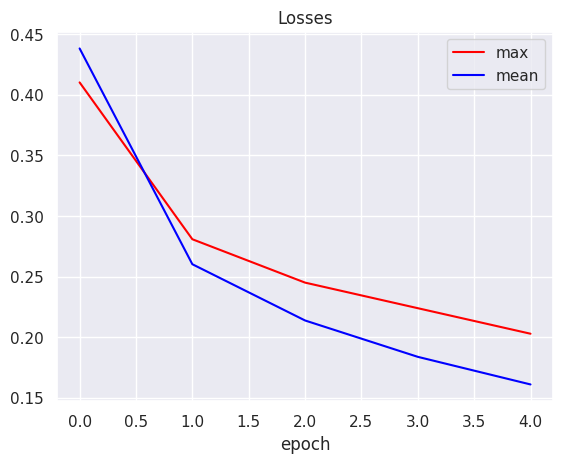

In [ ]:
plot_losses(losses_type)

In [18]:
def plot_accuracy(losses_type, acc_type):
  for (name, values), color in zip(losses_type.items(), ['red', 'blue']):
    plt.plot(np.arange(len(acc_type[name][1:])), acc_type[name][1:], color=color, label=name)
    print(f"Лучшая accuracy для подхода {name}: {(max(acc_type[name]) * 100):.2f}")

  plt.title('Accuracy')
  plt.xlabel("epoch")
  plt.legend()
  plt.show()

Лучшая accuracy для подхода max: 90.02
Лучшая accuracy для подхода mean: 90.62


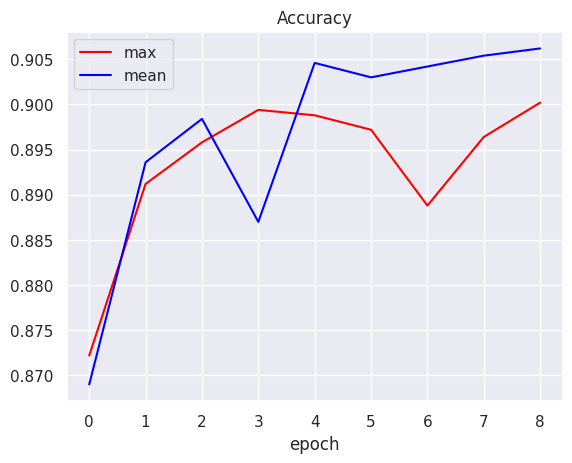

In [ ]:
plot_accuracy(losses_type, acc_type)

## Попытка использовать GRU вместо Vanilla

In [ ]:
class CharLMGRU(CharLM):
    def __init__(
        self, hidden_dim: int, vocab_size: int, num_classes: int = 4,
        aggregation_type: str = 'max'
        ):
        super().__init__(hidden_dim, vocab_size, num_classes,
        aggregation_type)
        self.rnn = nn.GRU(hidden_dim, hidden_dim, batch_first=True)

In [ ]:
num_epoch = 5
eval_steps = len(train_dataloader) // 2


losses_type = {}
acc_type = {}

for aggregation_type in ['max', 'mean']:
    print(f"Starting training for {aggregation_type}")
    losses = []
    acc = []

    model = CharLMGRU(hidden_dim=256, vocab_size=len(vocab), aggregation_type=aggregation_type).to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
    optimizer = torch.optim.Adam(model.parameters())

    for epoch in range(num_epoch):
        epoch_losses = []
        model.train()
        for i, batch in enumerate(tqdm(train_dataloader, desc=f'Training epoch {epoch}:')):
            optimizer.zero_grad()
            logits = model(batch['input_ids'])
            loss = criterion(logits, batch['label'])
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())
            if i % eval_steps == 0:
                model.eval()
                acc.append(evaluate(model, eval_dataloader))
                model.train()

        losses.append(sum(epoch_losses) / len(epoch_losses))

    losses_type[aggregation_type] = losses
    acc_type[aggregation_type] = acc

Starting training for max


Training epoch 0::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/3750 [00:00<?, ?it/s]

...

Training epoch 0::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/3750 [00:00<?, ?it/s]

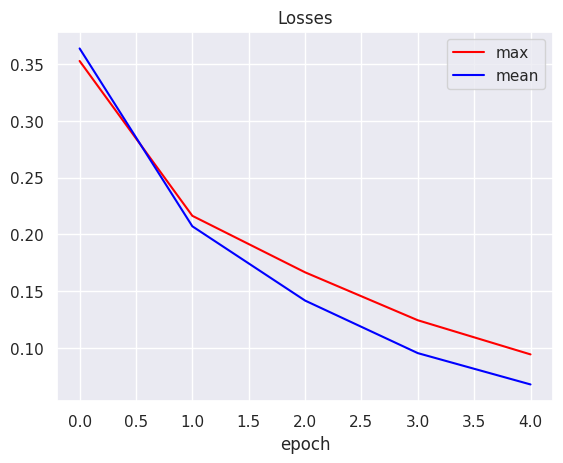

In [ ]:
plot_losses(losses_type)

Лучшая accuracy для подхода max: 91.38
Лучшая accuracy для подхода mean: 91.24


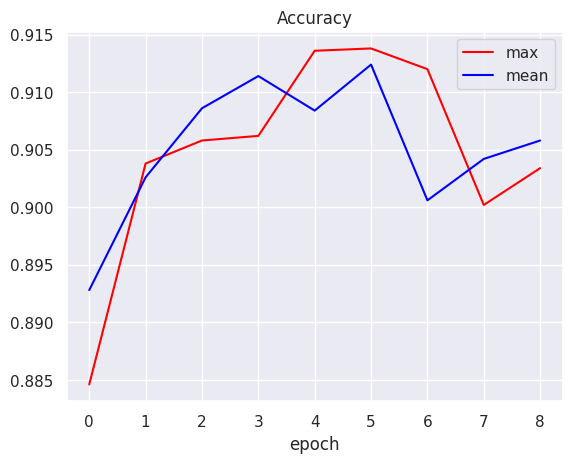

In [ ]:
plot_accuracy(losses_type, acc_type)

## Добавление реккурентных слоёв для лучшей модели

### 2 Слоя

In [ ]:
class CharLMGRU2(CharLM):
    def __init__(
        self, hidden_dim: int, vocab_size: int, num_classes: int = 4,
        aggregation_type: str = 'max'
        ):
        super().__init__(hidden_dim, vocab_size, num_classes,
        aggregation_type)
        self.rnn = nn.GRU(hidden_dim, hidden_dim, num_layers=2, batch_first=True)

In [ ]:
num_epoch = 5
eval_steps = len(train_dataloader) // 2


losses_type = {}
acc_type = {}

for aggregation_type in ['max', 'mean']:
    print(f"Starting training for {aggregation_type}")
    losses = []
    acc = []

    model = CharLMGRU2(hidden_dim=256, vocab_size=len(vocab), aggregation_type=aggregation_type).to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
    optimizer = torch.optim.Adam(model.parameters())

    for epoch in range(num_epoch):
        epoch_losses = []
        model.train()
        for i, batch in enumerate(tqdm(train_dataloader, desc=f'Training epoch {epoch}:')):
            optimizer.zero_grad()
            logits = model(batch['input_ids'])
            loss = criterion(logits, batch['label'])
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())
            if i % eval_steps == 0:
                model.eval()
                acc.append(evaluate(model, eval_dataloader))
                model.train()

        losses.append(sum(epoch_losses) / len(epoch_losses))

    losses_type[aggregation_type] = losses
    acc_type[aggregation_type] = acc

Starting training for max


Training epoch 0::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/3750 [00:00<?, ?it/s]

...

Training epoch 0::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/3750 [00:00<?, ?it/s]

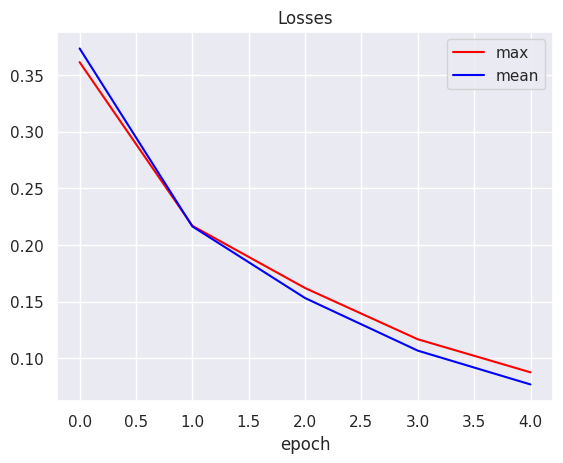

In [ ]:
plot_losses(losses_type)

Лучшая accuracy для подхода max: 91.56
Лучшая accuracy для подхода mean: 91.38


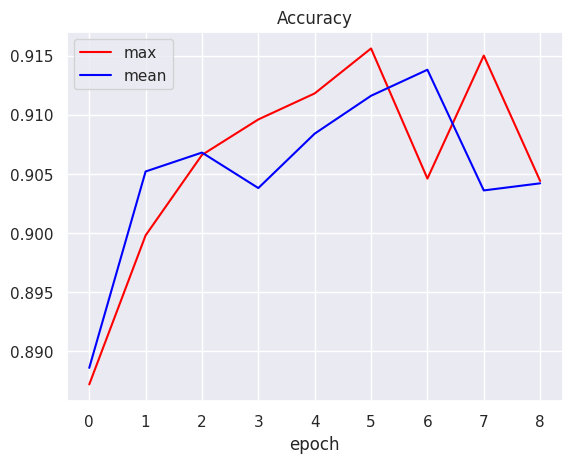

In [ ]:
plot_accuracy(losses_type, acc_type)

### 3 Слоя

In [ ]:
class CharLMGRU3(CharLM):
    def __init__(
        self, hidden_dim: int, vocab_size: int, num_classes: int = 4,
        aggregation_type: str = 'max'
        ):
        super().__init__(hidden_dim, vocab_size, num_classes,
        aggregation_type)
        self.rnn = nn.GRU(hidden_dim, hidden_dim, num_layers=3, batch_first=True)

In [ ]:
str(CharLMGRU3)[-12:-3]

'CharLMGRU3'

In [ ]:
num_epoch = 5
eval_steps = len(train_dataloader) // 2


losses_type = {}
acc_type = {}

for aggregation_type in ['max', 'mean']:
    print(f"Starting training for {aggregation_type}")
    losses = []
    acc = []

    model = CharLMGRU3(hidden_dim=256, vocab_size=len(vocab), aggregation_type=aggregation_type).to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
    optimizer = torch.optim.Adam(model.parameters())

    # добавил сохранение лучших весов модели:
    max_acc = 0.0
    for epoch in range(num_epoch):
        epoch_losses = []
        model.train()
        for i, batch in enumerate(tqdm(train_dataloader, desc=f'Training epoch {epoch}:')):
            optimizer.zero_grad()
            logits = model(batch['input_ids'])
            loss = criterion(logits, batch['label'])
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())
            if i % eval_steps == 0:
                model.eval()
                current_acc = evaluate(model, eval_dataloader)
                acc.append(current_acc)
                if current_acc > max_acc:
                    print(f"Обновление лучшей точности: {current_acc:.4f}.")
                    max_acc = current_acc
                    torch.save(model.state_dict(), f"best_W_for_{str(CharLMGRU3)[-12:-3]}_{aggregation_type}.pt")
                model.train()

        losses.append(sum(epoch_losses) / len(epoch_losses))

    losses_type[aggregation_type] = losses
    acc_type[aggregation_type] = acc

Starting training for max


Training epoch 0::   0%|          | 0/3750 [00:00<?, ?it/s]

Обновление лучшей точности: 0.2452.
Обновление лучшей точности: 0.8852.


Training epoch 1::   0%|          | 0/3750 [00:00<?, ?it/s]

Обновление лучшей точности: 0.9006.
Обновление лучшей точности: 0.9020.


...

Training epoch 2::   0%|          | 0/3750 [00:00<?, ?it/s]

Обновление лучшей точности: 0.9108.


Training epoch 3::   0%|          | 0/3750 [00:00<?, ?it/s]

Обновление лучшей точности: 0.9178.


Training epoch 4::   0%|          | 0/3750 [00:00<?, ?it/s]

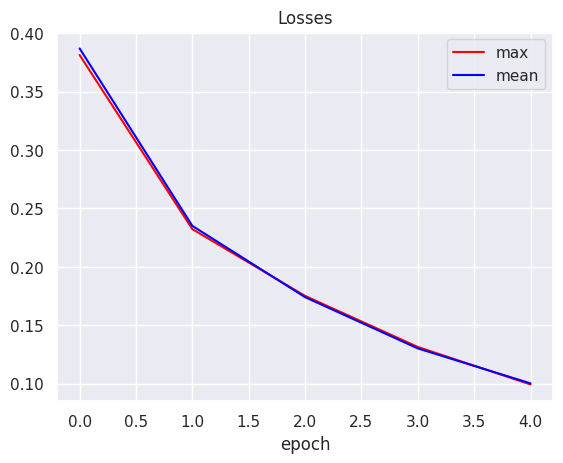

In [ ]:
plot_losses(losses_type)

Лучшая accuracy для подхода max: 91.20
Лучшая accuracy для подхода mean: 91.78


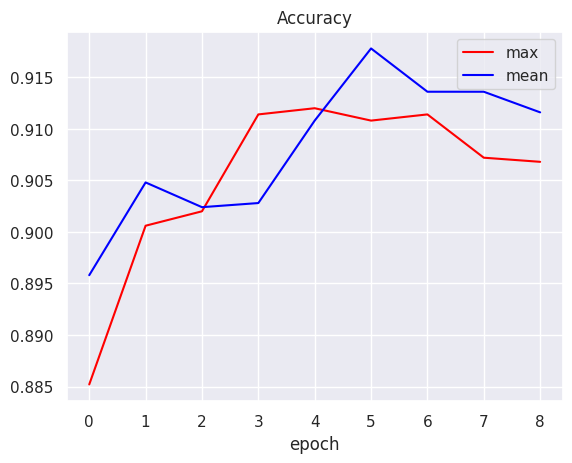

In [ ]:
plot_accuracy(losses_type, acc_type)

In [ ]:
str(CharLMGRU3)

"<class '__main__.CharLMGRU3'>"

In [ ]:
model = CharLMGRU3(hidden_dim=256, vocab_size=len(vocab), aggregation_type=aggregation_type).to(device)
model.load_state_dict(torch.load("/content/best_W_for_CharLMGRU_mean.pt"))

<All keys matched successfully>

In [ ]:
model.eval()
evaluate(model, eval_dataloader)

0.9177999496459961

## LSTM

In [ ]:
class CharLMLSTM(CharLM):
    def __init__(
        self, hidden_dim: int, vocab_size: int, num_classes: int = 4,
        aggregation_type: str = 'max'
        ):
        super().__init__(hidden_dim, vocab_size, num_classes,
        aggregation_type)
        self.rnn = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)


In [ ]:
model = CharLMLSTM(hidden_dim=256, vocab_size=len(vocab), aggregation_type=aggregation_type).to(device)
model

CharLMLSTM(
  (embedding): Embedding(11842, 256)
  (rnn): LSTM(256, 256, batch_first=True)
  (linear): Linear(in_features=256, out_features=256, bias=True)
  (projection): Linear(in_features=256, out_features=4, bias=True)
  (non_lin): Tanh()
  (dropout): Dropout(p=0.1, inplace=False)
)

In [ ]:
num_epoch = 5
eval_steps = len(train_dataloader) // 2


losses_type = {}
acc_type = {}

for aggregation_type in ['max', 'mean']:
    print(f"Starting training for {aggregation_type}")
    losses = []
    acc = []

    model = CharLMLSTM(hidden_dim=256, vocab_size=len(vocab), aggregation_type=aggregation_type).to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
    optimizer = torch.optim.Adam(model.parameters())

    # добавил сохранение лучших весов модели:
    max_acc = 0.0
    for epoch in range(num_epoch):
        epoch_losses = []
        model.train()
        for i, batch in enumerate(tqdm(train_dataloader, desc=f'Training epoch {epoch}:')):
            optimizer.zero_grad()
            logits = model(batch['input_ids'])
            loss = criterion(logits, batch['label'])
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())
            if i % eval_steps == 0:
                model.eval()
                current_acc = evaluate(model, eval_dataloader)
                acc.append(current_acc)
                if current_acc > max_acc:
                    print(f"Обновление лучшей точности: {current_acc:.4f}.")
                    max_acc = current_acc
                    torch.save(model.state_dict(), f"best_W_for_{str(CharLMLSTM)[-13:-2]}_{aggregation_type}.pt")
                model.train()

        losses.append(sum(epoch_losses) / len(epoch_losses))

    losses_type[aggregation_type] = losses
    acc_type[aggregation_type] = acc

Starting training for max


Training epoch 0::   0%|          | 0/3750 [00:00<?, ?it/s]

Обновление лучшей точности: 0.2568.
Обновление лучшей точности: 0.8926.


Training epoch 1::   0%|          | 0/3750 [00:00<?, ?it/s]

Обновление лучшей точности: 0.9072.
Обновление лучшей точности: 0.9080.


...

Обновление лучшей точности: 0.9102.


Training epoch 2::   0%|          | 0/3750 [00:00<?, ?it/s]

Обновление лучшей точности: 0.9148.


Training epoch 3::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/3750 [00:00<?, ?it/s]

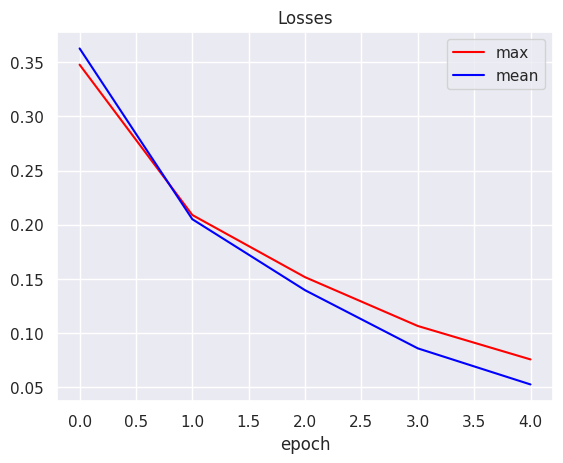

In [ ]:
plot_losses(losses_type)

Лучшая accuracy для подхода max: 90.80
Лучшая accuracy для подхода mean: 91.48


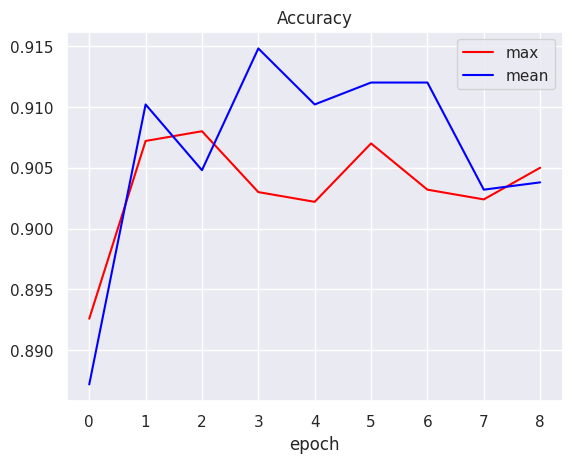

In [ ]:
plot_accuracy(losses_type, acc_type)

### 2 слоя

In [44]:
class CharLMLSTM2(CharLM):
    def __init__(
        self, hidden_dim: int, vocab_size: int, num_classes: int = 4,
        aggregation_type: str = 'max'
        ):
        super().__init__(hidden_dim, vocab_size, num_classes,
        aggregation_type)
        self.rnn = nn.LSTM(hidden_dim, hidden_dim, num_layers=2, batch_first=True)

In [45]:
str(CharLMLSTM2)[-13:-2]

'CharLMLSTM2'

In [46]:
num_epoch = 5
eval_steps = len(train_dataloader) // 2


losses_type = {}
acc_type = {}

for aggregation_type in ['max', 'mean']:
    print(f"Starting training for {aggregation_type}")
    losses = []
    acc = []

    model = CharLMLSTM2(hidden_dim=256, vocab_size=len(vocab), aggregation_type=aggregation_type).to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
    optimizer = torch.optim.Adam(model.parameters())

    # добавил сохранение лучших весов модели:
    max_acc = 0.0
    for epoch in range(num_epoch):
        epoch_losses = []
        model.train()
        for i, batch in enumerate(tqdm(train_dataloader, desc=f'Training epoch {epoch}:')):
            optimizer.zero_grad()
            logits = model(batch['input_ids'])
            loss = criterion(logits, batch['label'])
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())
            if i % eval_steps == 0:
                model.eval()
                current_acc = evaluate(model, eval_dataloader)
                acc.append(current_acc)
                if current_acc > max_acc:
                    print(f"Обновление лучшей точности: {current_acc:.4f}.")
                    max_acc = current_acc
                    torch.save(model.state_dict(), f"best_W_for_{str(CharLMLSTM2)[-13:-2]}_{aggregation_type}.pt")
                model.train()

        losses.append(sum(epoch_losses) / len(epoch_losses))

    losses_type[aggregation_type] = losses
    acc_type[aggregation_type] = acc

Starting training for max


Training epoch 0::   0%|          | 0/3750 [00:00<?, ?it/s]

Обновление лучшей точности: 0.2394.
Обновление лучшей точности: 0.8928.


Training epoch 1::   0%|          | 0/3750 [00:00<?, ?it/s]

Обновление лучшей точности: 0.9020.
Обновление лучшей точности: 0.9032.


...

Обновление лучшей точности: 0.9036.
Обновление лучшей точности: 0.9098.


Training epoch 2::   0%|          | 0/3750 [00:00<?, ?it/s]

Обновление лучшей точности: 0.9132.


Training epoch 3::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/3750 [00:00<?, ?it/s]

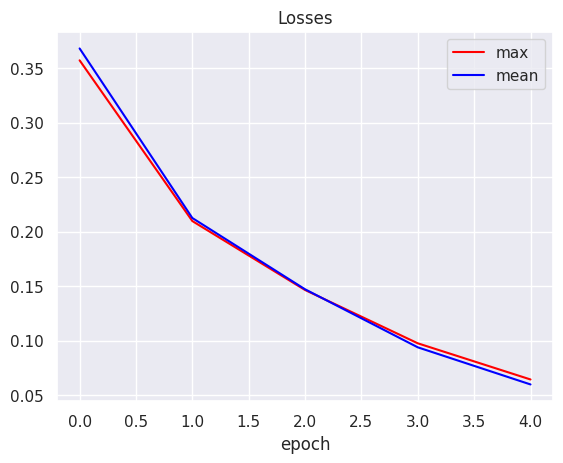

In [47]:
plot_losses(losses_type)

Лучшая accuracy для подхода max: 91.90
Лучшая accuracy для подхода mean: 91.32


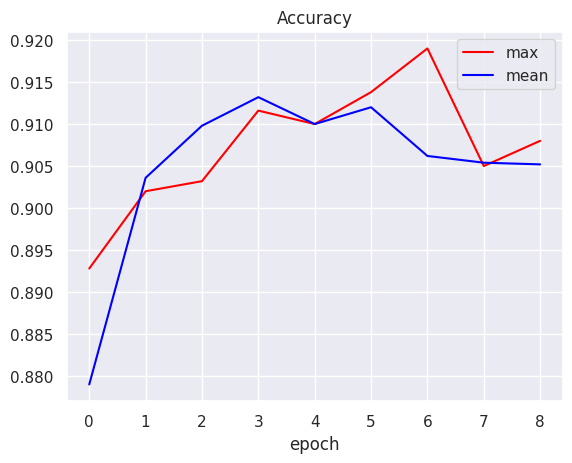

In [48]:
plot_accuracy(losses_type, acc_type)

### 3 слоя

In [ ]:
class CharLMLSTM3(CharLM):
    def __init__(
        self, hidden_dim: int, vocab_size: int, num_classes: int = 4,
        aggregation_type: str = 'max'
        ):
        super().__init__(hidden_dim, vocab_size, num_classes,
        aggregation_type)
        self.rnn = nn.LSTM(hidden_dim, hidden_dim, num_layers=3, batch_first=True)

In [ ]:
num_epoch = 5
eval_steps = len(train_dataloader) // 2


losses_type = {}
acc_type = {}

for aggregation_type in ['max', 'mean']:
    print(f"Starting training for {aggregation_type}")
    losses = []
    acc = []

    model = CharLMLSTM3(hidden_dim=256, vocab_size=len(vocab), aggregation_type=aggregation_type).to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
    optimizer = torch.optim.Adam(model.parameters())

    # добавил сохранение лучших весов модели:
    max_acc = 0.0
    for epoch in range(num_epoch):
        epoch_losses = []
        model.train()
        for i, batch in enumerate(tqdm(train_dataloader, desc=f'Training epoch {epoch}:')):
            optimizer.zero_grad()
            logits = model(batch['input_ids'])
            loss = criterion(logits, batch['label'])
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())
            if i % eval_steps == 0:
                model.eval()
                current_acc = evaluate(model, eval_dataloader)
                acc.append(current_acc)
                if current_acc > max_acc:
                    print(f"Обновление лучшей точности: {current_acc:.4f}.")
                    max_acc = current_acc
                    torch.save(model.state_dict(), f"best_W_for_{str(CharLMLSTM3)[-13:-2]}_{aggregation_type}.pt")
                model.train()

        losses.append(sum(epoch_losses) / len(epoch_losses))

    losses_type[aggregation_type] = losses
    acc_type[aggregation_type] = acc

Starting training for max


Training epoch 0::   0%|          | 0/3750 [00:00<?, ?it/s]

Обновление лучшей точности: 0.2470.
Обновление лучшей точности: 0.8796.


Training epoch 1::   0%|          | 0/3750 [00:00<?, ?it/s]

Обновление лучшей точности: 0.9018.
Обновление лучшей точности: 0.9122.


...

Обновление лучшей точности: 0.9098.


Training epoch 2::   0%|          | 0/3750 [00:00<?, ?it/s]

Обновление лучшей точности: 0.9136.


Training epoch 3::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/3750 [00:00<?, ?it/s]

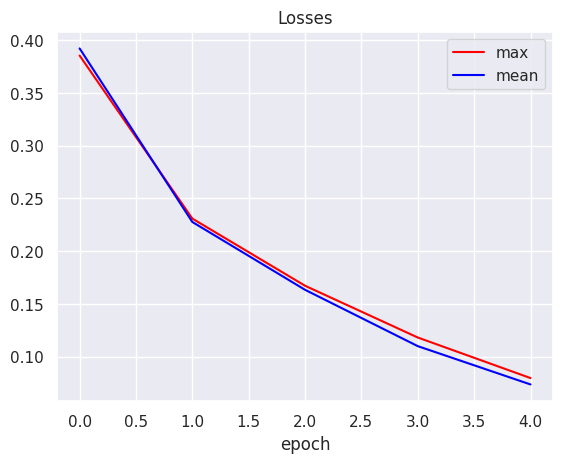

In [ ]:
plot_losses(losses_type)

Лучшая accuracy для подхода max: 91.22
Лучшая accuracy для подхода mean: 91.36


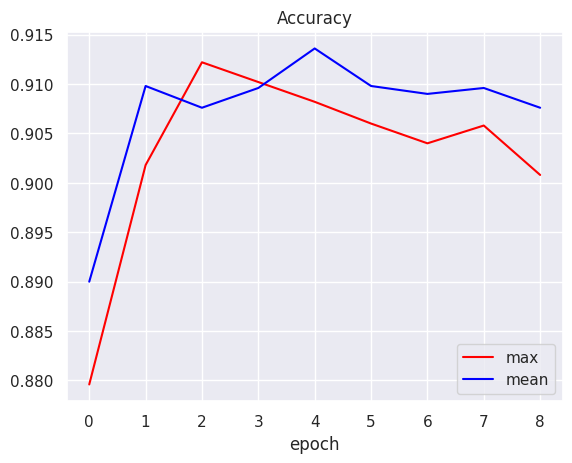

In [ ]:
plot_accuracy(losses_type, acc_type)

## Попытка конкатенировать результат агрегации и эмбеддинг с последнего токена.

In [ ]:
class CharLMConcat(CharLM):
    def __init__(
        self, hidden_dim: int, vocab_size: int, num_classes: int = 4,
        aggregation_type: str = 'max'
        ):
        super().__init__(hidden_dim, vocab_size, num_classes,
        aggregation_type)
        self.rnn = nn.RNN(hidden_dim, hidden_dim, batch_first=True)
        self.linear = nn.Linear(hidden_dim*2, hidden_dim)

    def forward(self, input_batch) -> torch.Tensor:
        embeddings = self.embedding(input_batch)  # [batch_size, seq_len, hidden_dim]
        output, _ = self.rnn(embeddings)  # [batch_size, seq_len, hidden_dim]

        if self.aggregation_type == 'max':
            aggregated = output.max(dim=1)[0] #[batch_size, hidden_dim]
        elif self.aggregation_type == 'mean':
            aggregated = output.mean(dim=1) #[batch_size, hidden_dim]
        else:
            raise ValueError("Invalid aggregation_type")

        last = output[:, -1, :]
        combined = torch.cat([aggregated, last], dim=1)
        output = self.dropout(self.linear(self.non_lin(combined)))  # [batch_size, hidden_dim]
        prediction = self.projection(self.non_lin(output))  # [batch_size, num_classes]

        return prediction

In [ ]:
num_epoch = 5
eval_steps = len(train_dataloader) // 2


losses_type = {}
acc_type = {}

for aggregation_type in ['max', 'mean']:
    print(f"Starting training for {aggregation_type}")
    losses = []
    acc = []

    model = CharLMConcat(hidden_dim=256, vocab_size=len(vocab), aggregation_type=aggregation_type).to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
    optimizer = torch.optim.Adam(model.parameters())

    # добавил сохранение лучших весов модели:
    max_acc = 0.0
    for epoch in range(num_epoch):
        epoch_losses = []
        model.train()
        for i, batch in enumerate(tqdm(train_dataloader, desc=f'Training epoch {epoch}:')):
            optimizer.zero_grad()
            logits = model(batch['input_ids'])
            loss = criterion(logits, batch['label'])
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())
            if i % eval_steps == 0:
                model.eval()
                current_acc = evaluate(model, eval_dataloader)
                acc.append(current_acc)
                if current_acc > max_acc:
                    print(f"Обновление лучшей точности: {current_acc:.4f}.")
                    max_acc = current_acc
                    torch.save(model.state_dict(), f"best_W_for_{str(CharLMConcat)[-14:-2]}_{aggregation_type}.pt")
                model.train()

        losses.append(sum(epoch_losses) / len(epoch_losses))

    losses_type[aggregation_type] = losses
    acc_type[aggregation_type] = acc

Starting training for max


Training epoch 0::   0%|          | 0/3750 [00:00<?, ?it/s]

Обновление лучшей точности: 0.2470.
Обновление лучшей точности: 0.8744.


Training epoch 1::   0%|          | 0/3750 [00:00<?, ?it/s]

Обновление лучшей точности: 0.8774.
Обновление лучшей точности: 0.8782.


...

Обновление лучшей точности: 0.8918.
Обновление лучшей точности: 0.8958.


Training epoch 2::   0%|          | 0/3750 [00:00<?, ?it/s]

Обновление лучшей точности: 0.9006.
Обновление лучшей точности: 0.9018.


Training epoch 3::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/3750 [00:00<?, ?it/s]

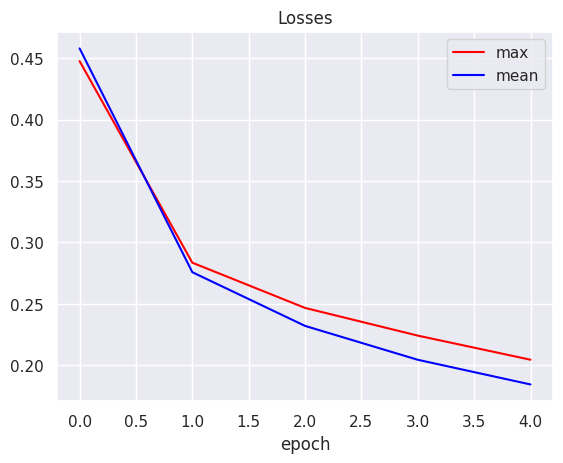

In [ ]:
plot_losses(losses_type)

Лучшая accuracy для подхода max: 90.84
Лучшая accuracy для подхода mean: 90.18


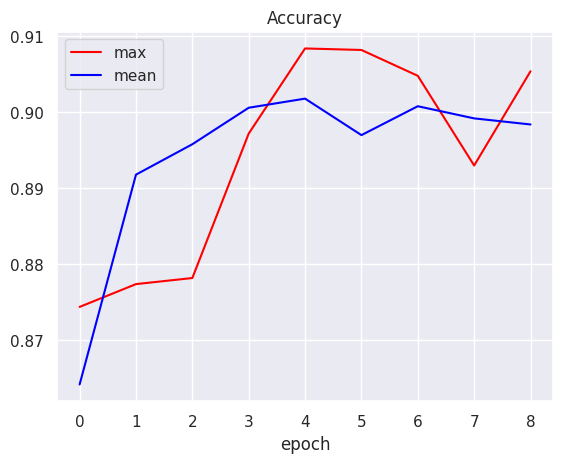

In [ ]:
plot_accuracy(losses_type, acc_type)

## GRU + 3 слоя + конкатенация

In [ ]:
class CharLMConcatGRU3(CharLMConcat):
    def __init__(
        self, hidden_dim: int, vocab_size: int, num_classes: int = 4,
        aggregation_type: str = 'max'
        ):
        super().__init__(hidden_dim, vocab_size, num_classes,
        aggregation_type)
        self.rnn = nn.GRU(hidden_dim, hidden_dim, num_layers=3, batch_first=True)



In [ ]:
num_epoch = 5
eval_steps = len(train_dataloader) // 2


losses_type = {}
acc_type = {}

for aggregation_type in ['max', 'mean']:
    print(f"Starting training for {aggregation_type}")
    losses = []
    acc = []

    model = CharLMConcatGRU3(hidden_dim=256, vocab_size=len(vocab), aggregation_type=aggregation_type).to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
    optimizer = torch.optim.Adam(model.parameters())

    # добавил сохранение лучших весов модели:
    max_acc = 0.0
    for epoch in range(num_epoch):
        epoch_losses = []
        model.train()
        for i, batch in enumerate(tqdm(train_dataloader, desc=f'Training epoch {epoch}:')):
            optimizer.zero_grad()
            logits = model(batch['input_ids'])
            loss = criterion(logits, batch['label'])
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())
            if i % eval_steps == 0:
                model.eval()
                current_acc = evaluate(model, eval_dataloader)
                acc.append(current_acc)
                if current_acc > max_acc:
                    print(f"Обновление лучшей точности: {current_acc:.4f}.")
                    max_acc = current_acc
                    torch.save(model.state_dict(), f"best_W_for_{str(CharLMConcatGRU3)[-14:-2]}_{aggregation_type}.pt")
                model.train()

        losses.append(sum(epoch_losses) / len(epoch_losses))

    losses_type[aggregation_type] = losses
    acc_type[aggregation_type] = acc

Starting training for max


Training epoch 0::   0%|          | 0/3750 [00:00<?, ?it/s]

Обновление лучшей точности: 0.2570.
Обновление лучшей точности: 0.8912.


Training epoch 1::   0%|          | 0/3750 [00:00<?, ?it/s]

Обновление лучшей точности: 0.8968.


...

Обновление лучшей точности: 0.9010.
Обновление лучшей точности: 0.9018.


Training epoch 2::   0%|          | 0/3750 [00:00<?, ?it/s]

Обновление лучшей точности: 0.9078.
Обновление лучшей точности: 0.9136.


Training epoch 3::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/3750 [00:00<?, ?it/s]

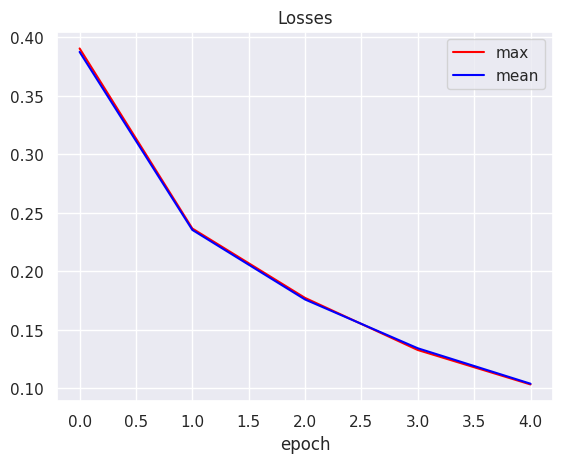

In [ ]:
plot_losses(losses_type)

Лучшая accuracy для подхода max: 91.64
Лучшая accuracy для подхода mean: 91.36


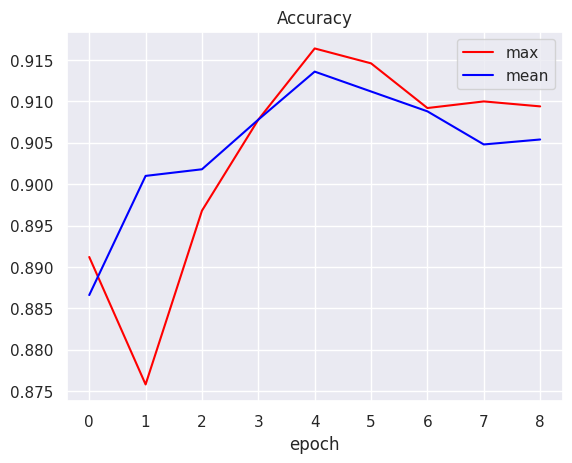

In [ ]:
plot_accuracy(losses_type, acc_type)

## Лучшя моедль - LSTM + 2 слоя

In [50]:
class CharLMLSTM2(CharLM):
    def __init__(
        self, hidden_dim: int, vocab_size: int, num_classes: int = 4,
        aggregation_type: str = 'max'
        ):
        super().__init__(hidden_dim, vocab_size, num_classes,
        aggregation_type)
        self.rnn = nn.LSTM(hidden_dim, hidden_dim, num_layers=2, batch_first=True)

In [56]:
aggregation_type = 'max'
model = CharLMLSTM2(hidden_dim=256, vocab_size=len(vocab), aggregation_type=aggregation_type).to(device)
model.load_state_dict(torch.load("/content/best_W_for_CharLMLSTM2_max.pt"))

<All keys matched successfully>

In [57]:
model.eval()
evaluate(model, eval_dataloader)

0.918999969959259

### Отчет

В этом разделе описаны проведенные эксперименты. В каждом эксперименте производилось одно архитектурное изменение по сравнению с базовой моделью. Были испробованы GRU, LSTM, конкатенация результата агрегации и эмбеддинга последнего токена выхода модели, а также увеличение числа рекуррентных слоев для GRU и LSTM.

Сравнение точности (accuracy):

1. **Базовая модель с семинара**: 0.9062

2. **Использование GRU**: 0.9138 (max)
   * GRU + 2 слоя: 0.9156 (max)
   * GRU + 3 слоя: 0.9178 (mean)

3. **Использование LSTM**: 0.9148 (mean)
   * **LSTM + 2 слоя**: **0.9190 (max)** — *лучший результат*
   * LSTM + 3 слоя: 0.9136 (mean)

4. **Конкатенация агрегации и эмбеддинга последнего токена**: 0.9084 (max)

5. **GRU + 3 слоя + агрегация**: 0.9164 (max)

---

Наилучший результат был получен с использованием LSTM и 2-х рекуррентных слоев — точность **0.9190 (max)**.

### Анализ экспериментов

* **Положительные изменения**: Все проведенные эксперименты дали прирост в точности по сравнению с базовой моделью с семинара. Наилучший изначальный прирост дало использование LSTM. Однако при увеличении числа слоев точность GRU оказалась выше.
Увеличение рекуррентных слоев также дало прирост точности. При этом для LSTM 2 слоя дали лучшую точность, чем 3, для GRU — наоборот.

* **Отрицательные изменения**: Попытка совместить два способа — применение GRU с 3 слоями + конкатенация (последний эксперимент) дала точность хоть и высокую, но меньше, чем просто использование GRU + 3 слоя.

### Графики сходимости и влияние эпох

Колебания являются существенными, особенно на последних эпохах. Как правило, лучшая точность моделей на валидационных данных достигалась на **3-й эпохе** (из 5), тогда как функция потерь на тренировочных данных стабильно уменьшалась. Это может свидетельствовать о **переобучении** моделей после 3 эпох.

### Оптимальная модель и идеи улучшения

Оптимальной получилась модель, которая отличается от базовой использованием **двух слоев LSTM** вместо одного стандартного рекуррентного слоя (точность на валидационных данных: **0.9190** с использованием агрегации по максимальному значению).

**Идеи по дальнейшему улучшению:**
1. Использование механизмов регуляризации (например, `Dropout` или `Weight Decay`) для борьбы с переобучением.
2. Внедрение планировщика шага обучения (Learning Rate Scheduler), чтобы плавно менять learning rate во время обучения моделей.
3. Использование предобученных векторных представлений (эмбеддингов, например FastText или GloVe) для улучшения качества инициализации.